# Enhancing House Price Prediction using Advanced Ensemble Learning and Stacking Techniques
- **Course:** IS403.Q13 - Business Data Analysis
- **Institute:** University of Information Technology, VNU-HCM
- **Date:** December 2025

**Team Members:**
| Name | Student ID | Email |
| :--- | :--- | :--- |
| **Thinh Vu** | 22521420 | 22521420@gm.uit.edu.vn |
| **Thinh Dinh** | 22521401 | 22521401@gm.uit.edu.vn |
| **Thanh Nguyen** | 22521352 | 22521352@gm.uit.edu.vn |

---

## 1. Setup and Configuration
We import necessary libraries, set global configurations for reproducibility, and define the plotting style.

In [1]:
import os
import warnings
from datetime import datetime

# Math & Data Manipulation
import numpy as np
import pandas as pd
from scipy.stats import skew
from scipy.special import boxcox1p

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing & Validation
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

# Machine Learning - Models
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LinearRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.ensemble import GradientBoostingRegressor, StackingRegressor

# Advanced Boosting Libraries
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Model Persistence
import joblib

# Global Configuration
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Libraries Loaded & Configuration Set.")

✅ Libraries Loaded & Configuration Set.


## 2. Evaluation Metric & Utility Functions

We evaluate performance using **Root Mean Squared Logarithmic Error (RMSLE)**. This metric penalizes relative errors, preventing expensive houses from skewing the loss function.

$$
\text{RMSLE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (\log(p_i + 1) - \log(a_i + 1))^2}
$$

**Implementation**: We train on `log1p(SalePrice)`.

- **RMSLE** is calculated on the log-scale predictions.
- **MAE ($)** and **MAPE (%)** are calculated by inverse-transforming (`expm1`) predictions back to real dollars.

## 3. Data Loading & Validation Strategy
We load the dataset and define our custom cross-validation strategy. We also define the **CustomGeometricBlender**, which allows us to blend models using a geometric mean to handle the log-transformed target variable.

In [2]:
# --- 1. Robust Data Loading ---
BASE_DIR = os.path.join("..", "data")
TRAIN_PATH = os.path.join(BASE_DIR, "train.csv")
TEST_PATH = os.path.join(BASE_DIR, "test.csv")

try:
    train = pd.read_csv(TRAIN_PATH)
    test = pd.read_csv(TEST_PATH)
    print(f"Data Loaded.\n  Train: {train.shape}\n  Test:  {test.shape}")
except FileNotFoundError:
    print(f"❌ ERROR: Data not found at {os.path.abspath(BASE_DIR)}")

# Save IDs for submission and drop from training
train_ID = train['Id']
test_ID = test['Id']
train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)

# --- 2. Custom Validation Function (RMSLE + Real Metrics) ---
n_folds = 5
kf = KFold(n_folds, shuffle=True, random_state=42)

def evaluate_model_cv(model, X, y):
    """
    Performs K-Fold CV. 
    Returns: Mean RMSLE (Log Scale), Mean MAE (Real $), Mean MAPE (%)
    """
    rmsle_scores, mae_scores, mape_scores = [], [], []
    
    # Handle pandas vs numpy input
    X_data = X.values if hasattr(X, "values") else X
    
    for train_idx, val_idx in kf.split(X_data, y):
        X_tr, X_val = X_data[train_idx], X_data[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        # Train Clone
        fold_model = clone(model)
        fold_model.fit(X_tr, y_tr)
        pred_log = fold_model.predict(X_val)
        
        # 1. RMSLE (Log Scale)
        rmsle = np.sqrt(mean_squared_error(y_val, pred_log))
        
        # 2. Real Dollar Metrics (Inverse Transform)
        pred_real = np.expm1(pred_log)
        y_real = np.expm1(y_val)
        
        mae = mean_absolute_error(y_real, pred_real)
        mape = mean_absolute_percentage_error(y_real, pred_real)
        
        rmsle_scores.append(rmsle)
        mae_scores.append(mae)
        mape_scores.append(mape)
        
    return np.mean(rmsle_scores), np.mean(mae_scores), np.mean(mape_scores)

# --- 3. Geometric Blender Class ---
class CustomGeometricBlender(BaseEstimator, RegressorMixin):
    """
    Blends models using Weighted Geometric Mean.
    Math: Geometric Mean in Real Space = Weighted Mean in Log Space.
    """
    def __init__(self, model1, model2, model3, w1=0.70, w2=0.15, w3=0.15):
        self.model1 = model1
        self.model2 = model2
        self.model3 = model3
        self.w1 = w1
        self.w2 = w2
        self.w3 = w3

    def fit(self, X, y):
        self.model1_ = clone(self.model1).fit(X, y)
        self.model2_ = clone(self.model2).fit(X, y)
        self.model3_ = clone(self.model3).fit(X, y)
        return self

    def predict(self, X):
        p1 = self.model1_.predict(X)
        p2 = self.model2_.predict(X)
        p3 = self.model3_.predict(X)
        return (self.w1 * p1) + (self.w2 * p2) + (self.w3 * p3)

print("✅ Validation functions ready.")

Data Loaded.
  Train: (1460, 81)
  Test:  (1459, 80)
✅ Validation functions ready.


## 4. Data Preprocessing & Feature Engineering
We process the raw data in four stages:
1.  **Outlier Removal & Target Transformation:** Removing anomalies (e.g., large agricultural lots) and **Log-Transforming** `SalePrice` to normalize its distribution.
2.  **Imputation:** Handling missing values based on column type (Categorical vs. Numerical).
3.  **Feature Synthesis:** Creating polynomials and interaction terms (e.g., `TotalSF`).
4.  **Transformation:** Applying **Box-Cox** to skewed features and One-Hot Encoding categorical variables.

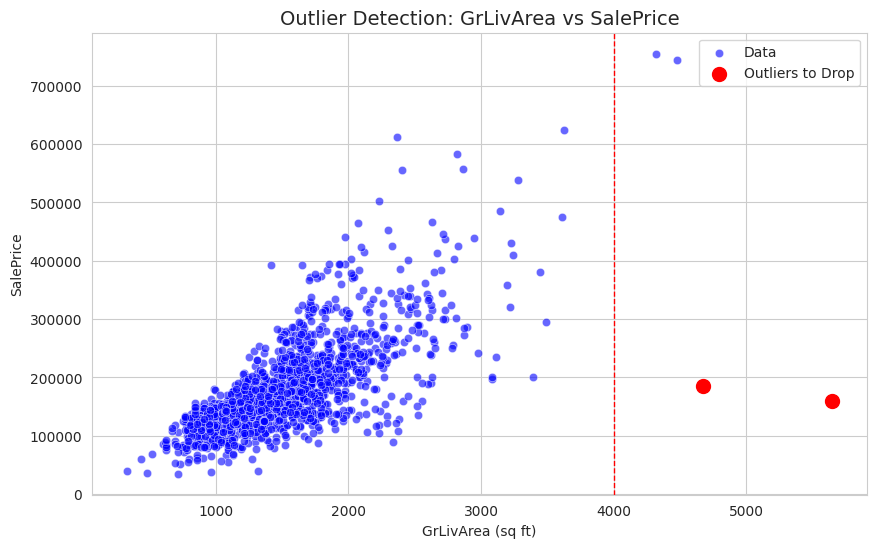

1. Outliers: Dropped 2 rows. Target Log-Transformed.


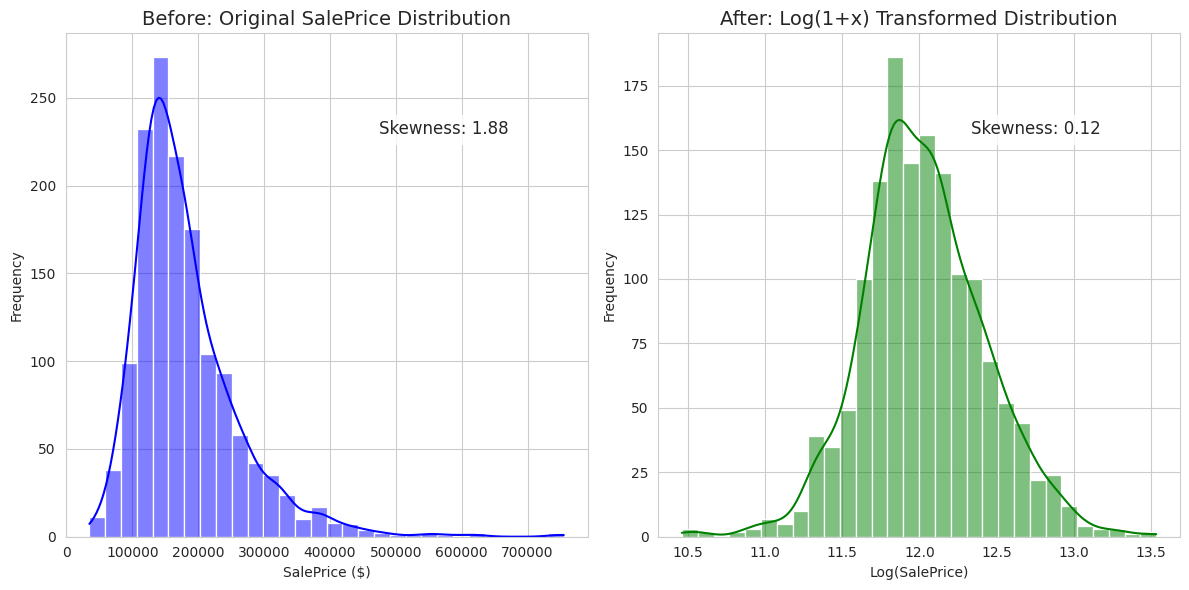

2. Imputation: Complete.


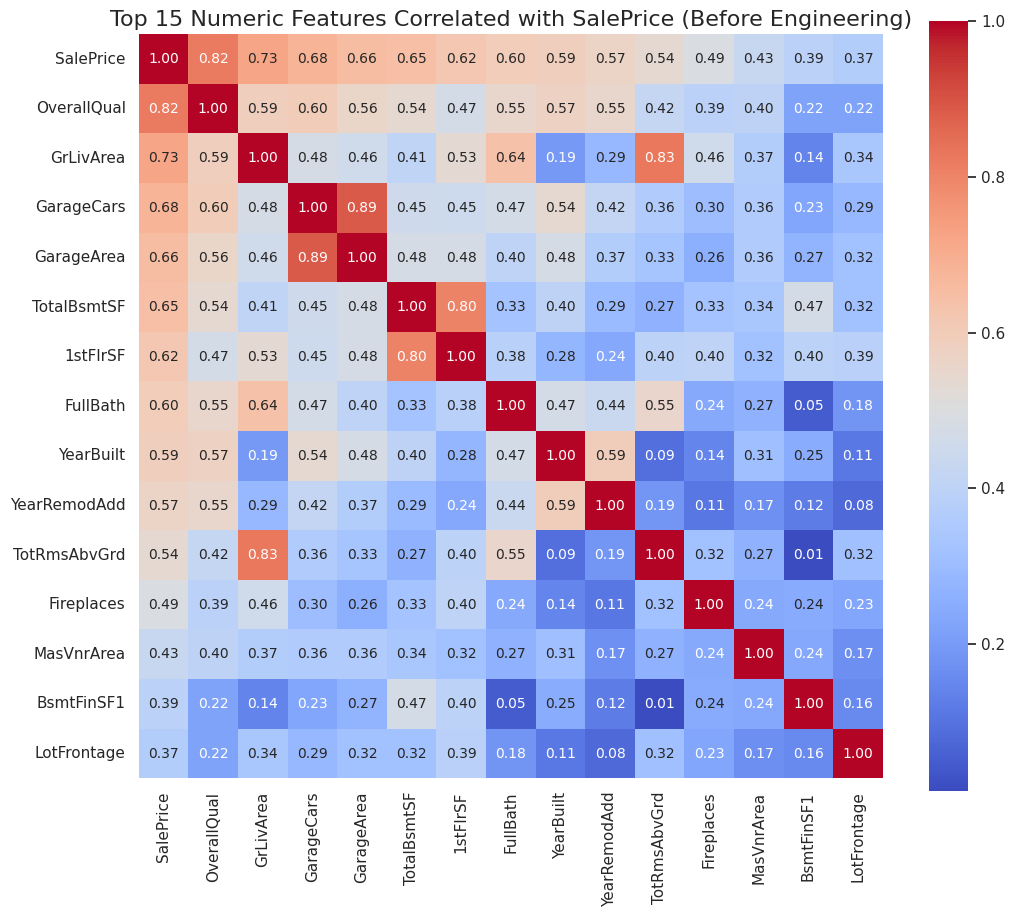

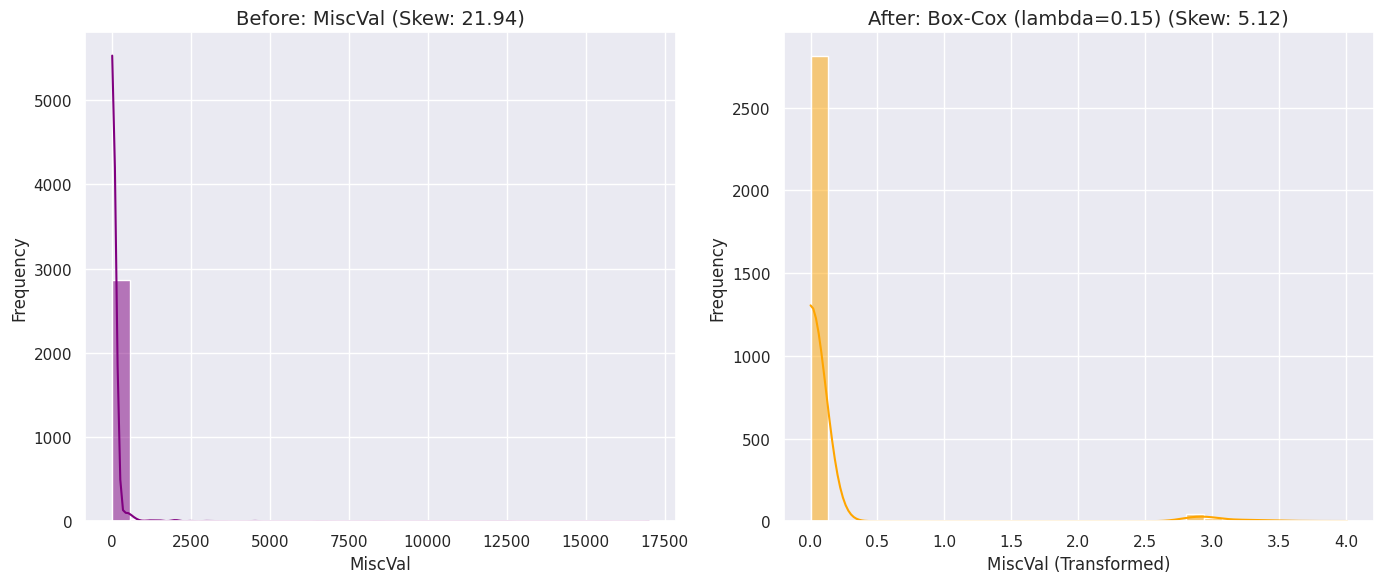

3. Feature Engineering: Complete. Final Shape: (1458, 224)


In [3]:
# --- Visualization: Outlier Detection (GrLivArea vs SalePrice) ---
plt.figure(figsize=(10, 6))

# Plot all data points
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'], color='blue', alpha=0.6, label='Data')

# Highlight the outliers we are about to drop (>4000 sqft and low price)
cutoff_price = 300000 if train['SalePrice'].max() > 100 else 12.5
outlier_mask = (train['GrLivArea'] > 4000) & (train['SalePrice'] < cutoff_price)
points_to_drop = train[outlier_mask]

plt.scatter(points_to_drop['GrLivArea'], points_to_drop['SalePrice'], 
            color='red', s=100, label='Outliers to Drop')

plt.axvline(x=4000, color='red', linestyle='--', linewidth=1)
plt.title("Outlier Detection: GrLivArea vs SalePrice", fontsize=14)
plt.xlabel("GrLivArea (sq ft)")
plt.ylabel("SalePrice")
plt.legend()
plt.show()

# --- Step 1: Outlier Removal & Target Transformation ---
# Drop agricultural outliers (> 4000 sqft, low price)
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < cutoff_price)]
train = train.drop(outliers.index).reset_index(drop=True)

# Original Distribution (Right-Skewed)
plt.subplot(1, 2, 1)
sns.histplot(train['SalePrice'], kde=True, color='blue', bins=30)
plt.title("Before: Original SalePrice Distribution", fontsize=14)
plt.xlabel("SalePrice ($)")
plt.ylabel("Frequency")
original_skew = skew(train['SalePrice'])
plt.text(0.6, 0.8, f"Skewness: {original_skew:.2f}", transform=plt.gca().transAxes, 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

# Log-Transform Target
train["SalePrice"] = np.log1p(train["SalePrice"])
y_train = train.SalePrice.values
print(f"1. Outliers: Dropped {len(outliers)} rows. Target Log-Transformed.")

# Log-Transformed Distribution (Normal-like)
plt.subplot(1, 2, 2)
sns.histplot(train['SalePrice'], kde=True, color='green', bins=30)
plt.title("After: Log(1+x) Transformed Distribution", fontsize=14)
plt.xlabel("Log(SalePrice)")
plt.ylabel("Frequency")
log_skew = skew(train['SalePrice'])
plt.text(0.6, 0.8, f"Skewness: {log_skew:.2f}", transform=plt.gca().transAxes, 
         fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# --- Step 2: Imputation ---
ntrain = train.shape[0]
ntest = test.shape[0]
all_data = pd.concat((train, test)).reset_index(drop=True)
all_data.drop(['SalePrice', 'Utilities'], axis=1, inplace=True, errors='ignore')

# Categorical "None" (No Garage, No Pool, etc.)
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "MasVnrType"]
for col in none_cols:
    all_data[col] = all_data[col].fillna("None")

# Numerical Zero
zero_cols = ["GarageYrBlt", "GarageArea", "GarageCars", "BsmtFinSF1", "BsmtFinSF2",
             "BsmtUnfSF", "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"]
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)

# Mode/Median
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median()))
mode_cols = ["MSZoning", "Electrical", "KitchenQual", "Exterior1st", "Exterior2nd", "SaleType", "Functional"]
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print("2. Imputation: Complete.")

# --- Visualization: Correlation Heatmap (Before Feature Engineering) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Select Numeric Features (excluding 'SalePrice' for now)
numeric_cols_before = all_data.select_dtypes(include=[np.number]).columns
analysis_df_before = all_data[numeric_cols_before].copy()

# 2. Add 'SalePrice' for correlation calculation (using the training part)
analysis_df_before = analysis_df_before.iloc[:ntrain]
analysis_df_before['SalePrice'] = y_train

# 3. Calculate Correlation Matrix
corr_matrix_before = analysis_df_before.corr()

# 4. Select Top K Predictors
k = 15
cols_before = corr_matrix_before.nlargest(k, 'SalePrice')['SalePrice'].index

# 5. Create the Heatmap
plt.figure(figsize=(12, 10))
cm_before = np.corrcoef(analysis_df_before[cols_before].dropna().values.T)
sns.set(font_scale=1.0)
sns.heatmap(cm_before, cbar=True, annot=True, square=True, fmt='.2f',
            annot_kws={'size': 10}, yticklabels=cols_before.values,
            xticklabels=cols_before.values, cmap='coolwarm')

plt.title(f"Top {k} Numeric Features Correlated with SalePrice (Before Engineering)", fontsize=16)
plt.show()

# --- Step 3: Feature Engineering ---
# Fix Types
for col in ['MSSubClass', 'OverallCond', 'YrSold', 'MoSold']:
    all_data[col] = all_data[col].astype(str)

# New Features (Interaction & Polynomials)
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']
all_data['TotalSF_Qual'] = all_data['TotalSF'] * all_data['OverallQual']
all_data['Year_Cond'] = all_data['YearBuilt'].astype(int) * all_data['OverallCond'].astype(int)
all_data['TotalSF_Sq'] = all_data['TotalSF'] ** 2
all_data['GrLivArea_Sq'] = all_data['GrLivArea'] ** 2

# --- Step 4: Encoding & Box-Cox ---
# Label Encode Ordinals
cols_ordinal = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond',
                'ExterQual', 'ExterCond', 'HeatingQC', 'PoolQC', 'KitchenQual',
                'BsmtFinType1', 'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure',
                'GarageFinish', 'LandSlope', 'LotShape', 'PavedDrive', 'Street',
                'Alley', 'CentralAir', 'MSSubClass', 'OverallCond', 'YrSold', 'MoSold')
for c in cols_ordinal:
    lbl = LabelEncoder()
    lbl.fit(list(all_data[c].values))
    all_data[c] = lbl.transform(list(all_data[c].values))

# Box-Cox Transformation for Skewed Features
numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewness = pd.DataFrame({'Skew': skewed_feats})
skewness = skewness[abs(skewness) > 0.75]

# --- Visualization: Feature Skewness (Before vs. After Box-Cox) ---
# We pick the most skewed feature to visualize the impact
top_skewed_feat = skewness.index[0] 
lam = 0.15 # The lambda value you are using

plt.figure(figsize=(14, 6))

# 1. Before Box-Cox
plt.subplot(1, 2, 1)
sns.histplot(all_data[top_skewed_feat], kde=True, color='purple', bins=30)
plt.title(f"Before: {top_skewed_feat} (Skew: {skewness.iloc[0,0]:.2f})", fontsize=14)
plt.xlabel(top_skewed_feat)
plt.ylabel("Frequency")

for feat in skewness.index:
    all_data[feat] = boxcox1p(all_data[feat], 0.15)

# 2. After Box-Cox (Simulated for visualization)
plt.subplot(1, 2, 2)
# We apply the transformation temporarily just for plotting
transformed_data = boxcox1p(all_data[top_skewed_feat], lam)
new_skew = skew(transformed_data)
sns.histplot(transformed_data, kde=True, color='orange', bins=30)
plt.title(f"After: Box-Cox (lambda={lam}) (Skew: {new_skew:.2f})", fontsize=14)
plt.xlabel(f"{top_skewed_feat} (Transformed)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# One-Hot Encoding
all_data = pd.get_dummies(all_data)
X_train = all_data[:ntrain]
X_test = all_data[ntrain:]

print(f"3. Feature Engineering: Complete. Final Shape: {X_train.shape}")

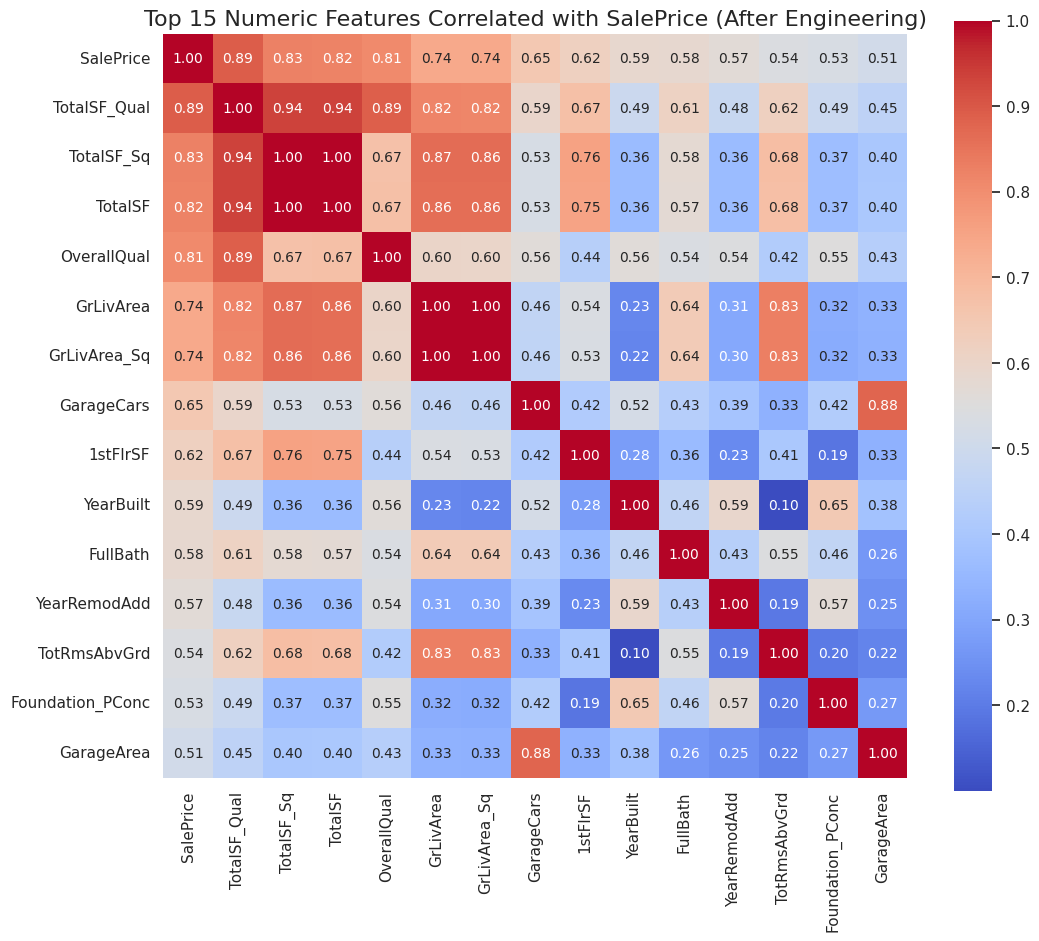

In [4]:
# --- Visualization: Top Correlated Numeric Features Heatmap ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Recombine X_train and y_train for analysis
# We create a temporary dataframe just for correlation calculation
analysis_df = X_train.copy()
analysis_df['SalePrice'] = y_train

# 2. Calculate Correlation Matrix using pandas first (more robust to NaNs)
corr_matrix = analysis_df.corr()

# 3. Select Top K Predictors
# We pick the top 15 features most correlated (positively or negatively) with SalePrice
k = 15 
cols = corr_matrix.nlargest(k, 'SalePrice')['SalePrice'].index

# 4. Create the Heatmap
# Move seaborn setup BEFORE creating the figure to avoid resetting the figure context
sns.set(font_scale=1.0)

# Use plt.subplots to explicitly create figure and axes objects
fig, ax = plt.subplots(figsize=(12, 10))

# Calculate correlation coefficient (dropping NaNs to be safe)
# Using pandas .corr() is generally safer and handles NaNs automatically
cm = analysis_df[cols].corr()

# Pass the axes object 'ax' to the heatmap function
sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', 
            annot_kws={'size': 10}, yticklabels=cols.values, 
            xticklabels=cols.values, cmap='coolwarm', ax=ax)

plt.title(f"Top {k} Numeric Features Correlated with SalePrice (After Engineering)", fontsize=16)
plt.show()

## 5. Modeling & Benchmarking Strategy
To maximize performance, we employ a multi-stage modeling and evaluation process.

### 5.1 Modeling Architecture
We utilize a two-tier ensemble approach:
1.  **Base Models:** A diverse set of robust linear models (Lasso, ElasticNet) and tree-based models (GradientBoosting, LightGBM, CatBoost).
2.  **Stacking:** The predictions of base models are fed into a meta-learner (XGBoost) to correct their biases.
3.  **Blending:** A weighted geometric mean combines the Stacking results with our strongest single models to ensure stability.

### 5.2 Benchmarking Process
We compare all models using **5-Fold Cross-Validation** to ensure the results are statistically valid. The leaderboard tracks three key metrics:
* **RMSLE:** The primary competition metric (Log-scale error).
* **MAE:** Mean Absolute Error (Average error in real dollars).
* **MAPE:** Mean Absolute Percentage Error (Average error percentage).

Model                     RMSLE      MAE ($)      MAPE (%)   Status
-----------------------------------------------------------------
Linear                    0.1301     14736         8.76%      (Done)
Lasso                     0.1121     13723         7.96%      (Done)
Ridge                     0.1136     13818         8.04%      (Done)
ElasticNet                0.1121     13706         7.96%      (Done)
KernelRidge               0.1178     14115         8.33%      (Done)
GradientBoosting          0.1163     13946         8.14%      (Done)
XGBoost                   0.1157     14214         8.13%      (Done)
LightGBM                  0.1159     13852         8.06%      (Done)
CatBoost                  0.1133     13619         7.81%      (Done)
Stacking_Ensemble         0.1111     13325         7.75%      (Done)
Geometric_Blend           0.1093     13106         7.61%      (Done)


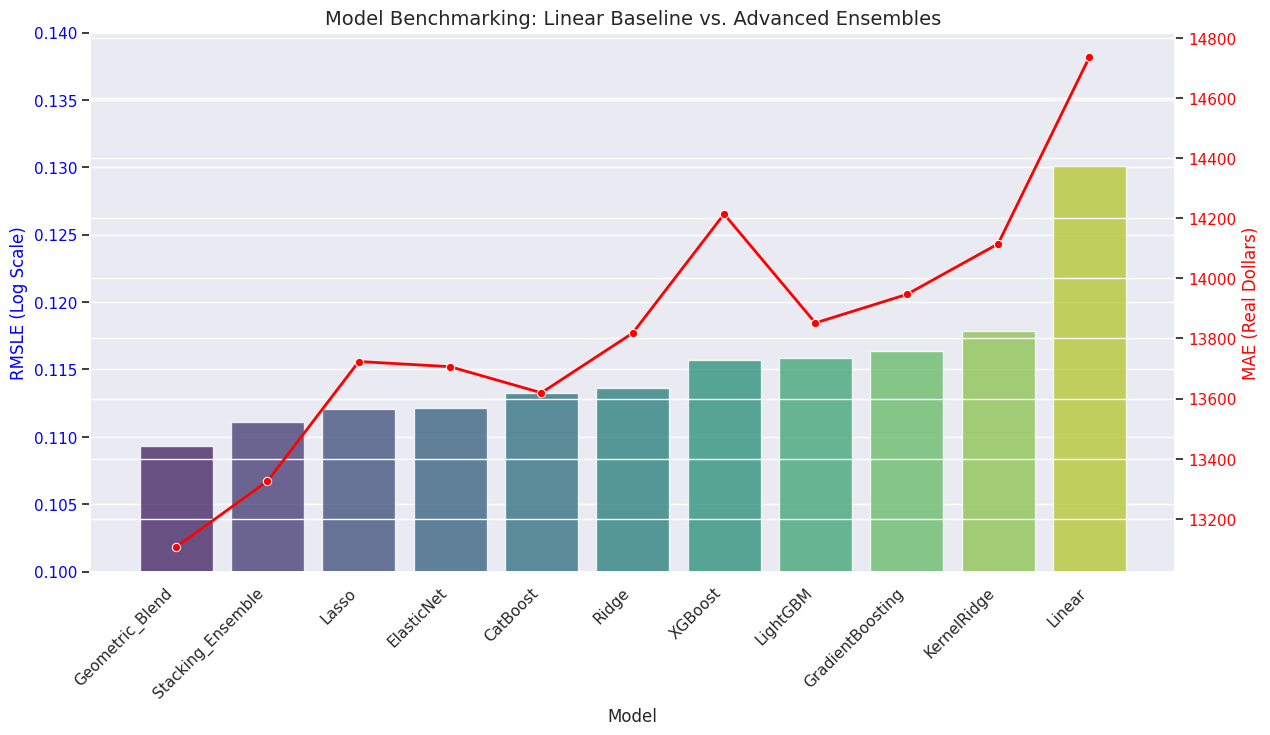


🏆 Final Leaderboard:


,Model,RMSLE,MAE,MAPE
10,Geometric_Blend,0.109347,13106.145692,0.076061
9,Stacking_Ensemble,0.111118,13325.029824,0.077537
1,Lasso,0.112074,13723.345170,0.079615
3,ElasticNet,0.112135,13706.095702,0.079559
8,CatBoost,0.113253,13619.179799,0.078119
2,Ridge,0.113617,13818.045646,0.080439
6,XGBoost,0.115683,14213.827130,0.081297
7,LightGBM,0.115865,13851.633364,0.080611
5,GradientBoosting,0.116346,13946.401687,0.081422
4,KernelRidge,0.117838,14114.688786,0.083319


In [5]:
# --- 1. Define Base Models ---
# Linear Models (We use RobustScaler to handle outliers)
linear = make_pipeline(RobustScaler(), LinearRegression())
lasso = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=1, max_iter=5000))
ridge =  make_pipeline(RobustScaler(), Ridge(alpha=10, random_state=42))
enet = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=3, max_iter=5000))
krr = KernelRidge(alpha=0.6, kernel='polynomial', degree=2, coef0=2.5)

# Tree Models
gboost = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05,
                                   max_depth=4, max_features='sqrt',
                                   min_samples_leaf=15, min_samples_split=10,
                                   loss='huber', random_state=5)

xgb_model = xgb.XGBRegressor(colsample_bytree=0.4603, gamma=0.0468, learning_rate=0.05, max_depth=3,
                             min_child_weight=1.7817, n_estimators=2200, reg_alpha=0.4640, reg_lambda=0.8571,
                             subsample=0.5213, random_state=7, nthread=-1)


lgb_model = lgb.LGBMRegressor(objective='regression', num_leaves=5, learning_rate=0.05, n_estimators=720,
                              max_bin=55, bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.2319,
                              feature_fraction_seed=9, bagging_seed=9, min_data_in_leaf=6, 
                              min_sum_hessian_in_leaf=11, verbose=-1)

cat_model = CatBoostRegressor(iterations=6000, learning_rate=0.005, depth=4, l2_leaf_reg=3, 
                              loss_function='RMSE', verbose=0, random_state=42)

# --- 2. Define Ensembles ---
# Stacking: Lasso/ENet/GB/LGBM -> Meta: XGBoost
stack_estimators = [('lasso', lasso), ('enet', enet), ('gb', gboost), ('lgb', lgb_model)]
stack_model = StackingRegressor(estimators=stack_estimators, final_estimator=xgb_model, cv=5, n_jobs=-1)


# Blending: 70% Stack, 15% CatBoost, 15% Lasso
blender_model = CustomGeometricBlender(model1=stack_model, model2=cat_model, model3=lasso, 
                                       w1=0.70, w2=0.15, w3=0.15)

# --- 3. Execute Benchmark ---
models_to_test = [
    ('Linear', linear),
    ('Lasso', lasso), 
    ('Ridge', ridge), 
    ('ElasticNet', enet), 
    ('KernelRidge', krr),
    ('GradientBoosting', gboost), 
    ('XGBoost', xgb_model), 
    ('LightGBM', lgb_model), 
    ('CatBoost', cat_model),
    ('Stacking_Ensemble', stack_model),
    ('Geometric_Blend', blender_model)
]

results_data = []
print(f"{'Model':<25} {'RMSLE':<10} {'MAE ($)':<12} {'MAPE (%)':<10} {'Status'}")
print("-" * 65)

for name, model in models_to_test:
    print(f"{name:<25} ...evaluating", end='\r')
    
    rmsle, mae, mape = evaluate_model_cv(model, X_train, y_train)
    
    results_data.append({'Model': name, 'RMSLE': rmsle, 'MAE': mae, 'MAPE': mape})
    print(f"{name:<25} {rmsle:.4f}     {mae:.0f}         {mape:.2%}      (Done)")

# --- 4. Visualization ---
leaderboard = pd.DataFrame(results_data).sort_values(by='RMSLE')

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar plot for RMSLE
sns.barplot(data=leaderboard, x='Model', y='RMSLE', ax=ax1, palette='viridis', alpha=0.8)
ax1.set_ylabel('RMSLE (Log Scale)', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0.10, 0.14) # Adjusted limit to show Linear Baseline (usually higher error)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Line plot for MAE
ax2 = ax1.twinx()
sns.lineplot(data=leaderboard, x='Model', y='MAE', ax=ax2, color='red', marker='o', linewidth=2, sort=False)
ax2.set_ylabel('MAE (Real Dollars)', color='red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Model Benchmarking: Linear Baseline vs. Advanced Ensembles", fontsize=14)
plt.show()

print("\n🏆 Final Leaderboard:")
display(leaderboard)

## 6. Model Interpretation
While ensemble models provide high accuracy, they can be difficult to interpret. To understand the "why" behind our predictions, we analyze the **Feature Importance** using our XGBoost model as a proxy.

1.  **Feature Importance:** Identifies which variables (e.g., `OverallQual`, `GrLivArea`) have the biggest impact on price.
2.  **Actual vs. Predicted:** A scatter plot to visualize how closely our model's predictions match reality (closer to the red line is better).

Fitting proxy model for interpretation...
Saved feature_importance.eps for LaTeX.


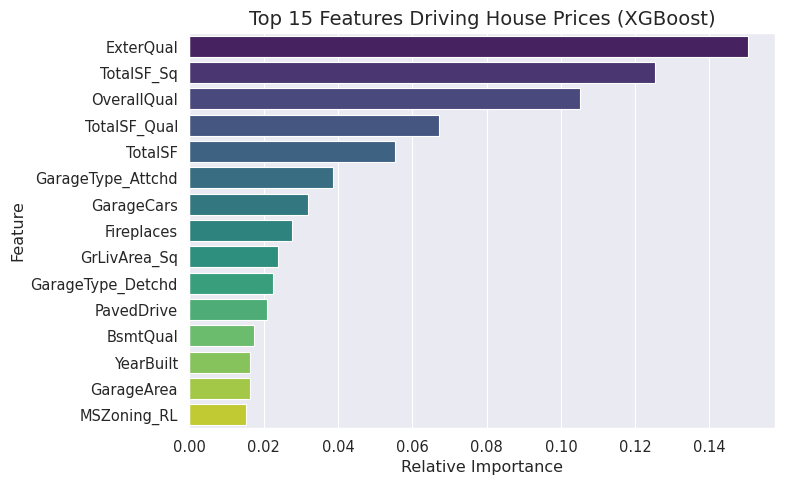

✅ Interpretation: These are the top variables our model uses to determine price.


In [6]:
# We must fit the proxy model explicitly before accessing feature_importances_
print("Fitting proxy model for interpretation...")
xgb_model.fit(X_train, y_train)

# 1. Extract Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Plot Top 15 Features (Changed from 20 to 15)
# figsize=(8, 5) is a good balance for LLNCS width vs height
plt.figure(figsize=(8, 5)) 

# Use sns.set_context to automatically scale fonts for "paper" or "talk"
sns.set_context("paper", font_scale=1.2) 

sns.barplot(data=importance.head(15), x='Importance', y='Feature', palette='viridis')

plt.title("Top 15 Features Driving House Prices (XGBoost)", fontsize=14)
plt.xlabel("Relative Importance")
plt.ylabel("Feature")
plt.tight_layout()

# 3. Save as EPS for high-quality LaTeX compiling
plt.savefig('feature_importance.eps', format='eps', dpi=300)
print("Saved feature_importance.eps for LaTeX.")

plt.show()

print("✅ Interpretation: These are the top variables our model uses to determine price.")

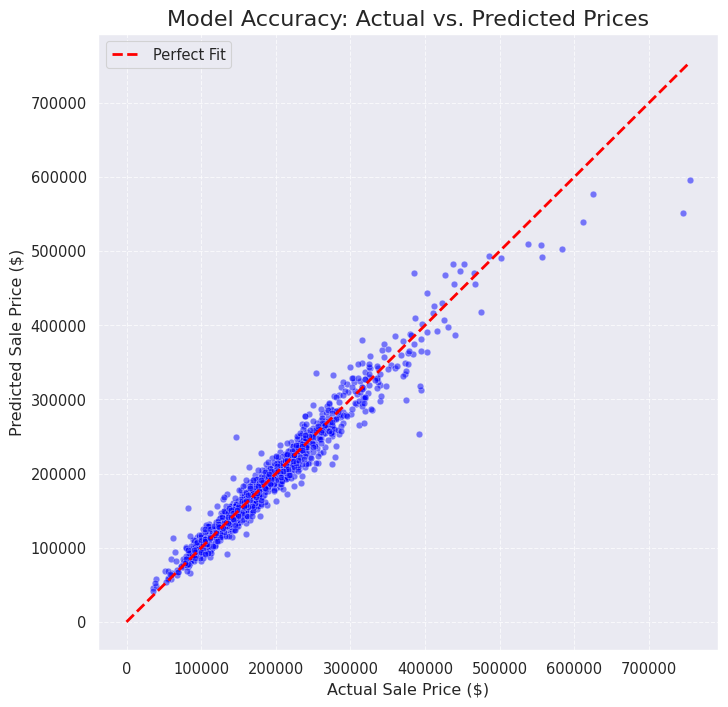

In [7]:
# --- Visualization: Actual vs. Predicted (Training Data) ---
# Generate predictions on training set to visualize fit
train_preds = np.expm1(xgb_model.predict(X_train))
y_true = np.expm1(y_train)

plt.figure(figsize=(8, 8))
sns.scatterplot(x=y_true, y=train_preds, alpha=0.5, color='blue')

# Plot a perfect diagonal line (Perfect Prediction)
max_val = max(y_true.max(), train_preds.max())
plt.plot([0, max_val], [0, max_val], '--', color='red', linewidth=2, label='Perfect Fit')

plt.title("Model Accuracy: Actual vs. Predicted Prices", fontsize=16)
plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 7. Final Prediction & Submission
We retrain the best-performing models on the **full training set** and generate the submission files.

In [8]:
# --- 1. Setup Directory ---
submission_dir = os.path.join("..", "submissions")
os.makedirs(submission_dir, exist_ok=True)

# Generate a timestamp for this batch of submissions (e.g., "2023-10-27_14-30")
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")

print(f"\n📂 Saving submissions to: {os.path.abspath(submission_dir)}")
print(f"🕒 Batch Timestamp: {timestamp}")
print(f"{'Model':<25} {'Status'}")
print("-" * 45)

# --- 2. Aggregate All Models ---
# We combine the base models and ensembles into one list for iteration
all_models = [
    ('Linear', linear),
    ('Lasso', lasso),
    ('Ridge', ridge),
    ('ElasticNet', enet),
    ('KernelRidge', krr),
    ('GradientBoosting', gboost),
    ('XGBoost', xgb_model),
    ('LightGBM', lgb_model),
    ('CatBoost', cat_model),
    ('Stacking_Ensemble', stack_model),
    ('Geometric_Blend', blender_model)
]

# --- 3. Train & Generate Loop ---
for name, model in all_models:
    # A. Fit on FULL Training Data
    model.fit(X_train, y_train)
    
    # B. Predict (Log Scale)
    pred_log = model.predict(X_test)
    
    # C. Inverse Transform (Real Dollars)
    pred_real = np.expm1(pred_log)
    
    # D. Save with Timestamp
    # Format: Submission_ModelName_Time.csv
    filename = f"Submission_{name}_{timestamp}.csv"
    filepath = os.path.join(submission_dir, filename)
    
    sub = pd.DataFrame({'Id': test_ID, 'SalePrice': pred_real})
    sub.to_csv(filepath, index=False)
    
    print(f"{name:<25} ✅ Saved")

print(f"\nAll {len(all_models)} submission files generated successfully.")


📂 Saving submissions to: /home/kakapt/code/python/house_price_analysis/submissions
🕒 Batch Timestamp: 2025-12-07_09-16
Model                     Status
---------------------------------------------
Linear                    ✅ Saved
Lasso                     ✅ Saved
Ridge                     ✅ Saved
ElasticNet                ✅ Saved
KernelRidge               ✅ Saved
GradientBoosting          ✅ Saved
XGBoost                   ✅ Saved
LightGBM                  ✅ Saved
CatBoost                  ✅ Saved
Stacking_Ensemble         ✅ Saved
Geometric_Blend           ✅ Saved

All 11 submission files generated successfully.


## 8. Deployment Preparation
We serialize (save) our trained models and preprocessing artifacts. This allows the models to be deployed in a production environment (e.g., a web app or API) without needing to retrain them.

In [9]:
# --- 1. Setup Directory ---
model_dir = os.path.join("..", "saved_models")
os.makedirs(model_dir, exist_ok=True)
print(f"\n📂 Saving assets to: {os.path.abspath(model_dir)}")
print("-" * 45)

# --- 2. Save Models ---
# We use the 'all_models' list created in the previous step
for name, model in all_models:
    # Save model object
    filename = f"{name}.pkl"
    filepath = os.path.join(model_dir, filename)
    joblib.dump(model, filepath)
    print(f"✅ Model Saved: {filename:<30} (Size: {os.path.getsize(filepath) / 1024:.1f} KB)")

# --- 3. Save Preprocessing Artifacts ---
# We save the stats used for imputation/transformation
# so new data can be processed exactly like the training data.
artifacts = {
    "features": X_train.columns.tolist(),
    "impute_modes": all_data.mode().iloc[0].to_dict(),
    "impute_medians": all_data.median(numeric_only=True).to_dict(),
    "skew_lambda": 0.15,  # The Box-Cox lambda we used
    "skewed_features": skewness.index.tolist()
}

joblib.dump(artifacts, os.path.join(model_dir, "artifacts.pkl"))
print(f"✅ Artifacts Saved: artifacts.pkl")


📂 Saving assets to: /home/kakapt/code/python/house_price_analysis/saved_models
---------------------------------------------
✅ Model Saved: Linear.pkl                     (Size: 12.0 KB)
✅ Model Saved: Lasso.pkl                      (Size: 10.4 KB)
✅ Model Saved: Ridge.pkl                      (Size: 10.3 KB)
✅ Model Saved: ElasticNet.pkl                 (Size: 10.4 KB)
✅ Model Saved: KernelRidge.pkl                (Size: 2567.5 KB)
✅ Model Saved: GradientBoosting.pkl           (Size: 4587.1 KB)
✅ Model Saved: XGBoost.pkl                    (Size: 1594.6 KB)
✅ Model Saved: LightGBM.pkl                   (Size: 451.3 KB)
✅ Model Saved: CatBoost.pkl                   (Size: 1933.8 KB)
✅ Model Saved: Stacking_Ensemble.pkl          (Size: 13263.9 KB)
✅ Model Saved: Geometric_Blend.pkl            (Size: 23753.3 KB)
✅ Artifacts Saved: artifacts.pkl


## 9. Conclusion & Results

In this project, we successfully developed a high-performance ensemble machine learning pipeline.

### **Key Results**
- **Top Performance:** Our **Geometric Blend** strategy achieved the lowest error with an RMSLE of **0.1093**.
- **Improvement:** This represents a **16.0% improvement** over the baseline Linear Regression model (RMSLE 0.1301).
- **Surprising Insight:** Among standalone models, **Lasso (RMSLE 0.1121)** outperformed complex tree-based models like CatBoost and XGBoost. This indicates that our feature engineering (Box-Cox transformations and RobustScaling) successfully linearized the relationships in the data, making simple, interpretable models highly effective.

### **Business Impact**
- **Accuracy:** The final model achieves a Mean Absolute Error (MAE) of **\$13,106**.
- **Interpretation:** On average, our price predictions are within **~\$13k** of the actual market value. Given the average house price in the dataset (~$180k), this represents a remarkably low error rate (MAPE) of just **7.6%**.